<a href="https://colab.research.google.com/github/PaolaPina3228/Simulaci-n-2/blob/main/C%C3%B3digo_Simulaci%C3%B3n_de_Inventarios_utilizando_Python_Un_Estudio_del_Modelo_de_Revisi%C3%B3n_Continua_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fecha: Ene-2021, Ventas reales: 76, Demanda ajustada: 69.09
Fecha: Feb-2021, Ventas reales: 87, Demanda ajustada: 82.86
Fecha: Mar-2021, Ventas reales: 73, Demanda ajustada: 76.84
Fecha: Abr-2021, Ventas reales: 82, Demanda ajustada: 82.00
Fecha: May-2021, Ventas reales: 62, Demanda ajustada: 68.89
Fecha: Jun-2021, Ventas reales: 58, Demanda ajustada: 68.24
Fecha: Jul-2021, Ventas reales: 46, Demanda ajustada: 57.50
Fecha: Ago-2021, Ventas reales: 67, Demanda ajustada: 78.82
Fecha: Sep-2021, Ventas reales: 76, Demanda ajustada: 80.00
Fecha: Oct-2021, Ventas reales: 69, Demanda ajustada: 69.00
Fecha: Nov-2021, Ventas reales: 78, Demanda ajustada: 70.91
Fecha: Dic-2021, Ventas reales: 90, Demanda ajustada: 75.00
Fecha: Ene-2022, Ventas reales: 75, Demanda ajustada: 68.18
Fecha: Feb-2022, Ventas reales: 84, Demanda ajustada: 80.00
Fecha: Mar-2022, Ventas reales: 70, Demanda ajustada: 73.68
Fecha: Abr-2022, Ventas reales: 79, Demanda ajustada: 79.00
Fecha: May-2022, Ventas reales: 69, Dema

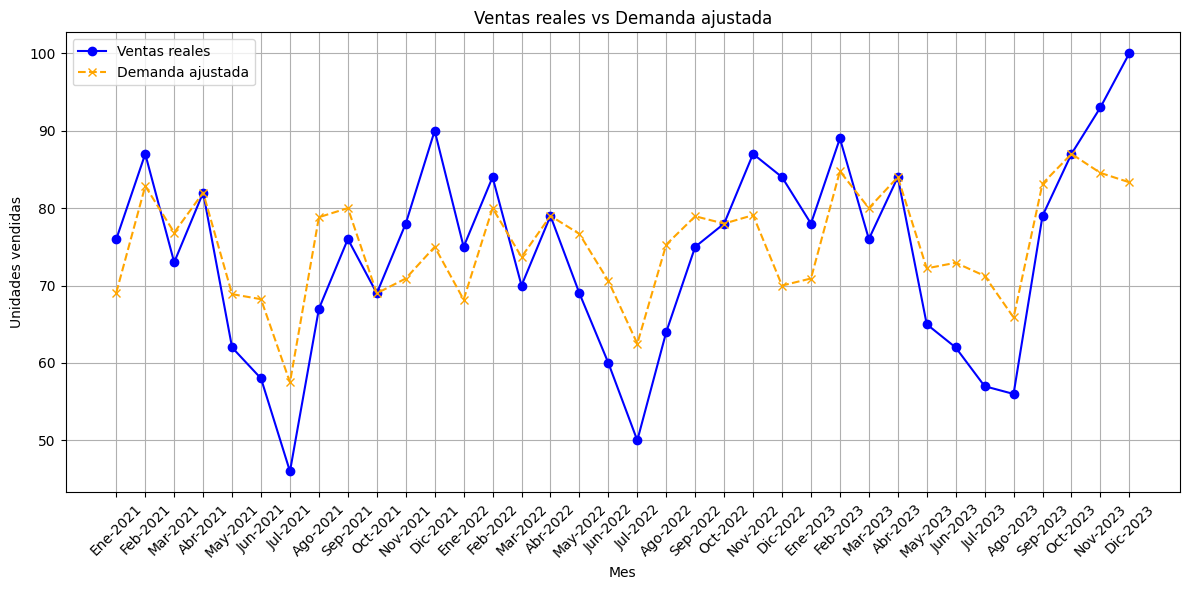

In [5]:
# Datos de demanda histórica
fechas = ["Ene-2021", "Feb-2021", "Mar-2021", "Abr-2021", "May-2021", "Jun-2021", "Jul-2021", "Ago-2021", "Sep-2021", "Oct-2021", "Nov-2021", "Dic-2021",
          "Ene-2022", "Feb-2022", "Mar-2022", "Abr-2022", "May-2022", "Jun-2022", "Jul-2022", "Ago-2022", "Sep-2022", "Oct-2022", "Nov-2022", "Dic-2022",
          "Ene-2023", "Feb-2023", "Mar-2023", "Abr-2023", "May-2023", "Jun-2023", "Jul-2023", "Ago-2023", "Sep-2023", "Oct-2023", "Nov-2023", "Dic-2023"]

ventas = [76, 87, 73, 82, 62, 58, 46, 67, 76, 69, 78, 90,
          75, 84, 70, 79, 69, 60, 50, 64, 75, 78, 87, 84,
          78, 89, 76, 84, 65, 62, 57, 56, 79, 87, 93, 100]

# Factores estacionales para cada mes
factores_estacionales = [1.1, 1.05, 0.95, 1.0, 0.9, 0.85, 0.8, 0.85, 0.95, 1.0, 1.1, 1.2]

# Calcular la demanda ajustada para cada mes
demanda_ajustada = []
for i in range(len(ventas)):
    mes = i % 12  # Determinar el mes (0 = Enero, 1 = Febrero, ..., 11 = Diciembre)
    ajuste = ventas[i] / factores_estacionales[mes]  # Ajustar según el factor estacional
    demanda_ajustada.append(ajuste)

# Mostrar los resultados
for i in range(len(ventas)):
    print(f"Fecha: {fechas[i]}, Ventas reales: {ventas[i]}, Demanda ajustada: {demanda_ajustada[i]:.2f}")

# Graficar las ventas reales y la demanda ajustada
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(fechas, ventas, label="Ventas reales", marker='o', color="blue")
plt.plot(fechas, demanda_ajustada, label="Demanda ajustada", linestyle='--', marker='x', color="orange")
plt.title("Ventas reales vs Demanda ajustada")
plt.xlabel("Mes")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


2: Stock agotado. Unidades faltantes: 13.289473684210535
3: Pedido realizado. Stock actual: 0.0
8: Pedido recibido. Stock actualizado: 100.0
9: Pedido realizado. Stock actual: 20.0
14: Pedido recibido. Stock actualizado: 120.0
15: Pedido realizado. Stock actual: 49.41176470588235
20: Pedido recibido. Stock actualizado: 149.41176470588235
21: Stock agotado. Unidades faltantes: 3.4973262032085586
22: Pedido realizado. Stock actual: 0.0
27: Pedido recibido. Stock actualizado: 100.0
28: Pedido realizado. Stock actual: 20.0
33: Pedido recibido. Stock actualizado: 120.0
34: Pedido realizado. Stock actual: 40.0
39: Pedido recibido. Stock actualizado: 140.0
40: Stock agotado. Unidades faltantes: 27.619047619047606
41: Pedido realizado. Stock actual: 0.0
46: Pedido recibido. Stock actualizado: 100.0
47: Pedido realizado. Stock actual: 24.705882352941174
52: Pedido recibido. Stock actualizado: 124.70588235294117
53: Pedido realizado. Stock actual: 40.705882352941174
58: Pedido recibido. Stock ac

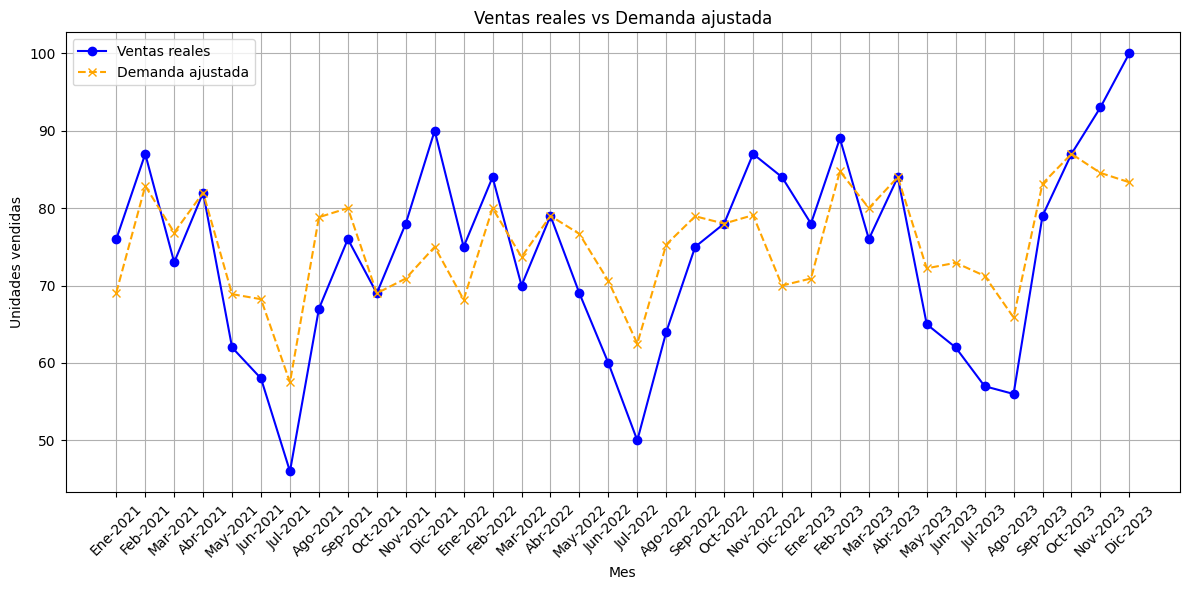

In [8]:
# Importar bibliotecas necesarias
!pip install simpy
import simpy
import numpy as np
import matplotlib.pyplot as plt

# Datos de demanda histórica
fechas = ["Ene-2021", "Feb-2021", "Mar-2021", "Abr-2021", "May-2021", "Jun-2021", "Jul-2021", "Ago-2021", "Sep-2021", "Oct-2021", "Nov-2021", "Dic-2021",
          "Ene-2022", "Feb-2022", "Mar-2022", "Abr-2022", "May-2022", "Jun-2022", "Jul-2022", "Ago-2022", "Sep-2022", "Oct-2022", "Nov-2022", "Dic-2022",
          "Ene-2023", "Feb-2023", "Mar-2023", "Abr-2023", "May-2023", "Jun-2023", "Jul-2023", "Ago-2023", "Sep-2023", "Oct-2023", "Nov-2023", "Dic-2023"]

ventas = [76, 87, 73, 82, 62, 58, 46, 67, 76, 69, 78, 90,
          75, 84, 70, 79, 69, 60, 50, 64, 75, 78, 87, 84,
          78, 89, 76, 84, 65, 62, 57, 56, 79, 87, 93, 100]

# Factores estacionales para cada mes
factores_estacionales = [1.1, 1.05, 0.95, 1.0, 0.9, 0.85, 0.8, 0.85, 0.95, 1.0, 1.1, 1.2]

# Calcular la demanda ajustada para cada mes
demanda_ajustada = []
for i in range(len(ventas)):
    mes = i % 12  # Determinar el mes
    ajuste = ventas[i] / factores_estacionales[mes]
    demanda_ajustada.append(ajuste)

# Parámetros del modelo
REORDER_POINT = 50  # Nivel de reorden
ORDER_QUANTITY = 100  # Cantidad de pedido
STOCK_INITIAL = 200  # Inventario inicial
COST_STORAGE = 0.5  # Costo por unidad en almacenamiento
COST_SHORTAGE = 5  # Costo por unidad no satisfecha

# Simulación con SimPy
class Inventario:
    def __init__(self, env, stock_inicial):
        self.env = env
        self.stock = simpy.Container(env, init=stock_inicial)
        self.action = env.process(self.gestionar_inventario())

    def gestionar_inventario(self):
        while True:
            # Revisar si se necesita reabastecer
            if self.stock.level < REORDER_POINT:
                print(f"{self.env.now}: Pedido realizado. Stock actual: {self.stock.level}")
                yield self.env.timeout(5)  # Tiempo de entrega del pedido
                self.stock.put(ORDER_QUANTITY)
                print(f"{self.env.now}: Pedido recibido. Stock actualizado: {self.stock.level}")

            # Simular consumo de la demanda diaria
            demanda = np.random.choice(demanda_ajustada)  # Escoger demanda ajustada
            if self.stock.level >= demanda:
                self.stock.get(demanda)
            else:
                faltante = demanda - self.stock.level
                self.stock.get(self.stock.level)  # Consumir todo el inventario
                print(f"{self.env.now}: Stock agotado. Unidades faltantes: {faltante}")

            yield self.env.timeout(1)  # Simular un día

# Configurar el entorno y ejecutar la simulación
env = simpy.Environment()
inventario = Inventario(env, STOCK_INITIAL)
env.run(until=365)  # Simular un año

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.plot(fechas, ventas, label="Ventas reales", marker='o', color="blue")
plt.plot(fechas, demanda_ajustada, label="Demanda ajustada", linestyle='--', marker='x', color="orange")
plt.title("Ventas reales vs Demanda ajustada")
plt.xlabel("Mes")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
